In [1]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]
df = df[(constant.JPSI_MASS-50 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+50)]

In [2]:
# df, _ = filter_duplicates_by_performance(df, "Bplus_ENDVERTEX_CHI2", "min")
# df, _ = filter_duplicates_by_performance(df, "Kplus_PIDK", "max")

In [3]:
import zfit
import zfit.plot
import matplotlib.pyplot as plt
import scipy

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-02-17 02:04:25.203934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739757865.220036 4152048 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739757865.225183 4152048 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
bounds = (5000, 6000)

# Define the observable (entire range of the data)
obs = zfit.Space("m", limits=bounds)

data_np = df["Bplus_M"].to_numpy()
data_np = data_np[(data_np > bounds[0]) & (data_np < bounds[1])]

print(f"{len(data_np)=}")

data = zfit.Data.from_numpy(array=data_np, obs=obs)

mu = zfit.param.ConstantParameter("mu", constant.BPLUS_MASS) # fix gaussian mean

fwhm = 23
sigma_from_fwhm = fwhm * 0.424661

sigma = zfit.Parameter("sigma", sigma_from_fwhm, floating=False) # fixed sigma

lambda_ = zfit.Parameter("lambda", -0.001)

# calculate a crude upper limit for Nsig for parameter bounds
full_pm_20MeV_yield = len(df[(df["Bplus_M"] < constant.BPLUS_MASS + 20) & (df["Bplus_M"] > constant.BPLUS_MASS - 20)])

# Define the yields (Nsig and Nbkg)
Nsig = zfit.Parameter("Nsig", 0, 0, full_pm_20MeV_yield)  # Floating signal yield
Nbkg = zfit.Parameter("Nbkg", 800)  # Floating background yield

signal = zfit.pdf.Gauss(mu=mu, sigma=sigma, obs=obs).create_extended(Nsig)
background = zfit.pdf.Exponential(lam=lambda_, obs=obs).create_extended(Nbkg)

total = zfit.pdf.SumPDF([signal, background])

nll = zfit.loss.ExtendedUnbinnedNLL(model=total, data=data)

minimizer = zfit.minimize.Minuit()
minimum = minimizer.minimize(nll)
minimum.hesse()

print(minimum)

len(data_np)=825


2025-02-17 02:04:29.866619: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-02-17 02:04:29.866765: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.86.15 -- cannot find working devices in this configuration


FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('m',) shape=(825, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═══════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │  edm  │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═══════╪══════════════════════════════╡
│  True   │    True     │      False       │ 3e-05 │           5640.28 |  10005.8 │
╘═════════╧═════════════╧══════════════════╧═══════╧══════════════════════════════╛

Parameters
name      value  (rounded)        hesse    at limit
------  ------------------  -----------  ----------
Nsig               3.43579  +/-     6.3       False
Nbkg               821.671  +/-      29       False
lambda         -0.00137682  +/- 0.00013       False


Text(0, 1, '$-\\log(\\mathcal{L})$')

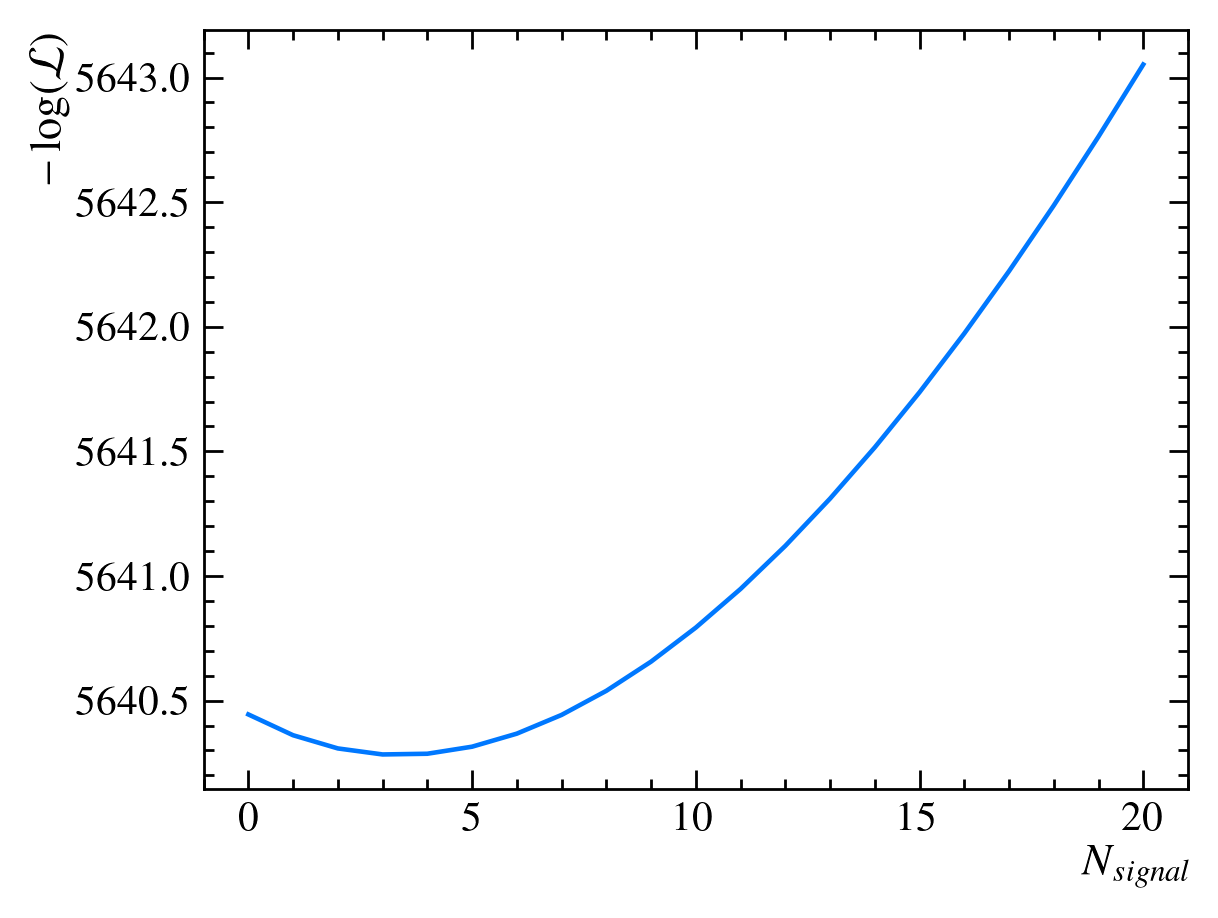

In [5]:
test_points = np.linspace(0, 20, 21)
nll_vals = []
for point in test_points:
    Nsig.set_value(point)
    nll_vals.append(nll.value().numpy())
    
# Plot to visualize
plt.plot(test_points, nll_vals)
plt.xlabel(r'$N_{signal}$')
plt.ylabel(r'$-\log(\mathcal{L})$')

In [6]:
def find_upper_limit(
    nll: zfit.loss.ExtendedUnbinnedNLL,
    Nsig: zfit.Parameter,
    minimum: zfit.result.FitResult,
    ndof=1,
    alpha=0.05, # CL = 1 - alpha
):
    def nll_from_Nsig(
        x: float, nll: zfit.loss.ExtendedUnbinnedNLL, Nsig: zfit.Parameter
    ):
        Nsig.set_value(x)
        return nll.value().numpy()

    nll_Nsig_hat = minimum.fmin  # i.e. minimum of nll
    Nsig_hat = float(minimum.params[Nsig]["value"])

    target_nll = scipy.stats.chi2.isf(alpha, ndof) / 2 + nll_Nsig_hat

    ul_Nsig: scipy.optimize.OptimizeResult = scipy.optimize.minimize_scalar(
        lambda x: abs(target_nll - nll_from_Nsig(x, nll, Nsig)),
        bounds=(Nsig_hat, float(Nsig.upper)),
    )

    return ul_Nsig.x

print(f"Upper limit for signal yield Nsig: {find_upper_limit(nll, Nsig, minimum)} at 95% CL using a chi-squared distribution")

print(f"{minimum.params}")

Upper limit for signal yield Nsig: 16.92045378866625 at 95% CL using a chi-squared distribution
name      value  (rounded)        hesse    at limit
------  ------------------  -----------  ----------
Nsig               3.43579  +/-     6.3       False
Nbkg               821.671  +/-      29       False
lambda         -0.00137682  +/- 0.00013       False


In [7]:
import scipy.integrate


points = np.linspace(0, full_pm_20MeV_yield, 10_000)
likelihoods = []
for point in points:
    Nsig.set_value(point)
    likelihoods.append(nll.value().numpy())

likelihoods = np.array(likelihoods)

likelihoods -= likelihoods.min()

# norm = scipy.integrate.simpson(likelihoods, dx = full_pm_20MeV_yield/3000)
def find_first_95_percent(pdf):
   cumsum = np.cumsum(pdf) / np.sum(pdf)
   upper_index = np.argmax(cumsum >= 0.95)
   return upper_index

ul_index = find_first_95_percent(np.exp(-likelihoods))

Upper limit 16.3716


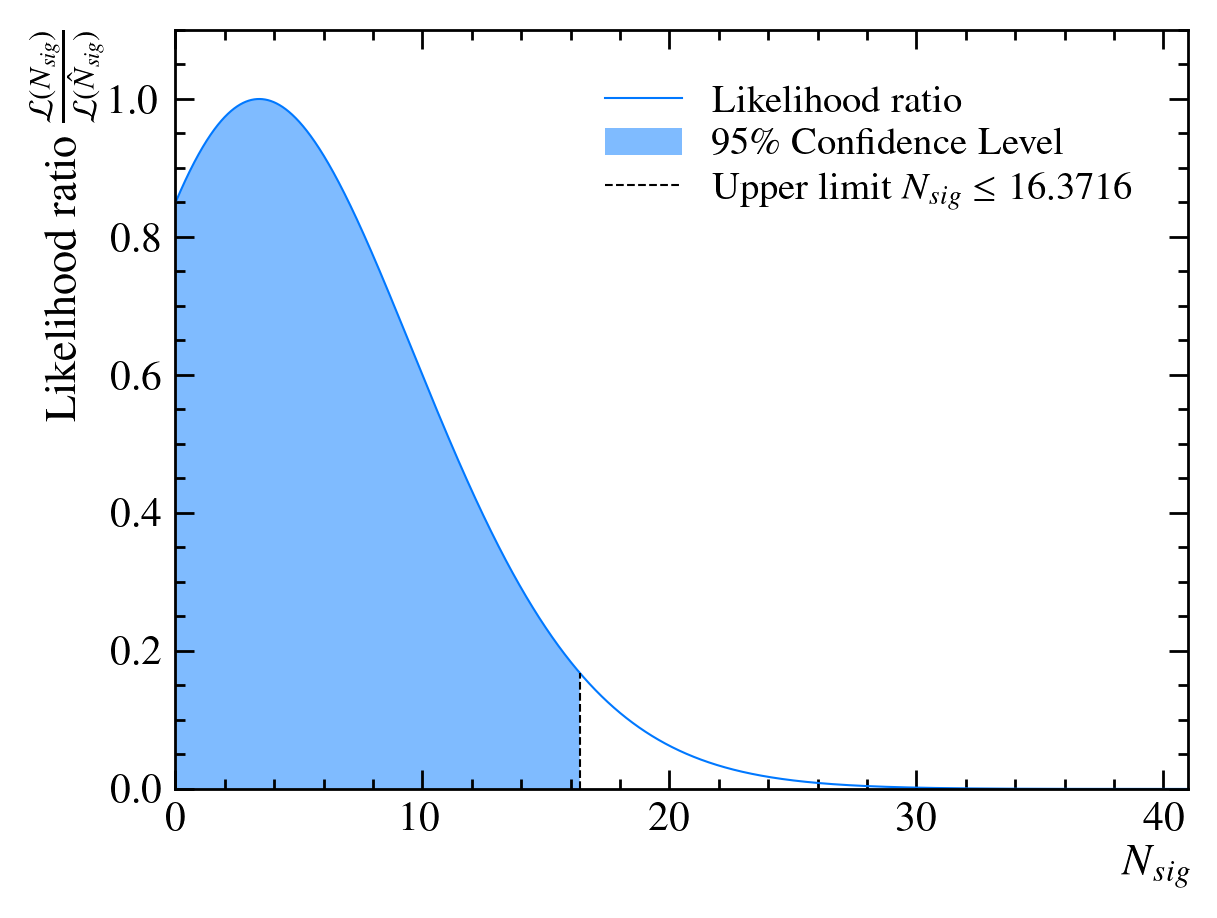

In [8]:
fig, ax = plt.subplots()


ax.plot(points, np.exp(-likelihoods), label="Likelihood ratio", linewidth=1.5)
ax.set(
    xlabel=r"$N_{sig}$",
    ylabel=r"Likelihood ratio $\frac{\mathcal{L}(N_{sig})}{\mathcal{L}(\hat{N}_{sig})}$",
)

ax.fill_between(
    points[:ul_index], np.exp(-likelihoods)[:ul_index], alpha=0.5, label=r"$95\%$ Confidence Level"
)

ax.plot(
    [points[:ul_index][-1]] * 2,
    [0, np.exp(-likelihoods)[:ul_index][-1]],
    color="k",
    linestyle="--",
    linewidth=1.5,
    label=fr"Upper limit $N_{{sig}} \leq {ul_index * full_pm_20MeV_yield/10_000}$",
)

ax.set(xlim=[0,41], ylim=[0,1.1])

ax.legend()

print(f"Upper limit {ul_index * full_pm_20MeV_yield/10_000}")

Histogram not saved to file
Histogram not saved to file


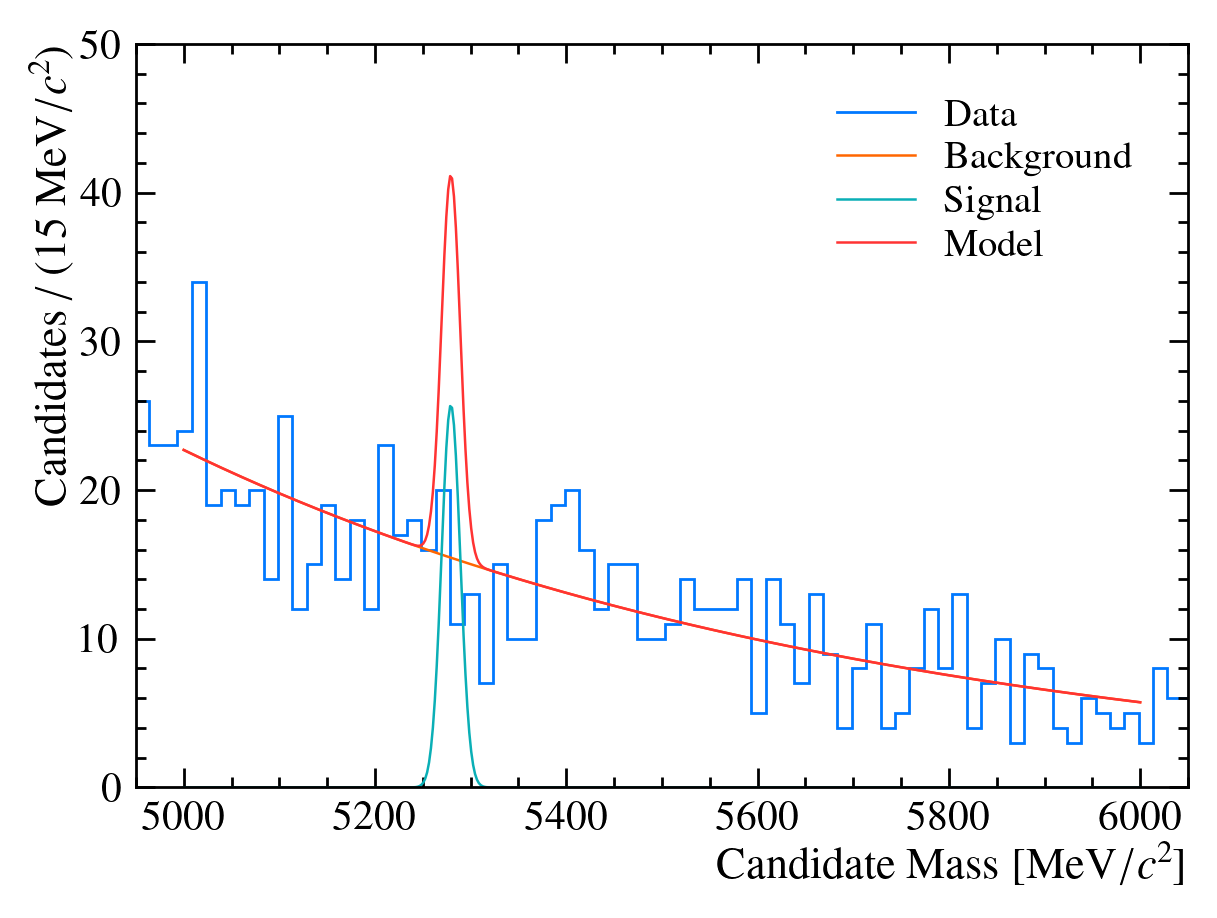

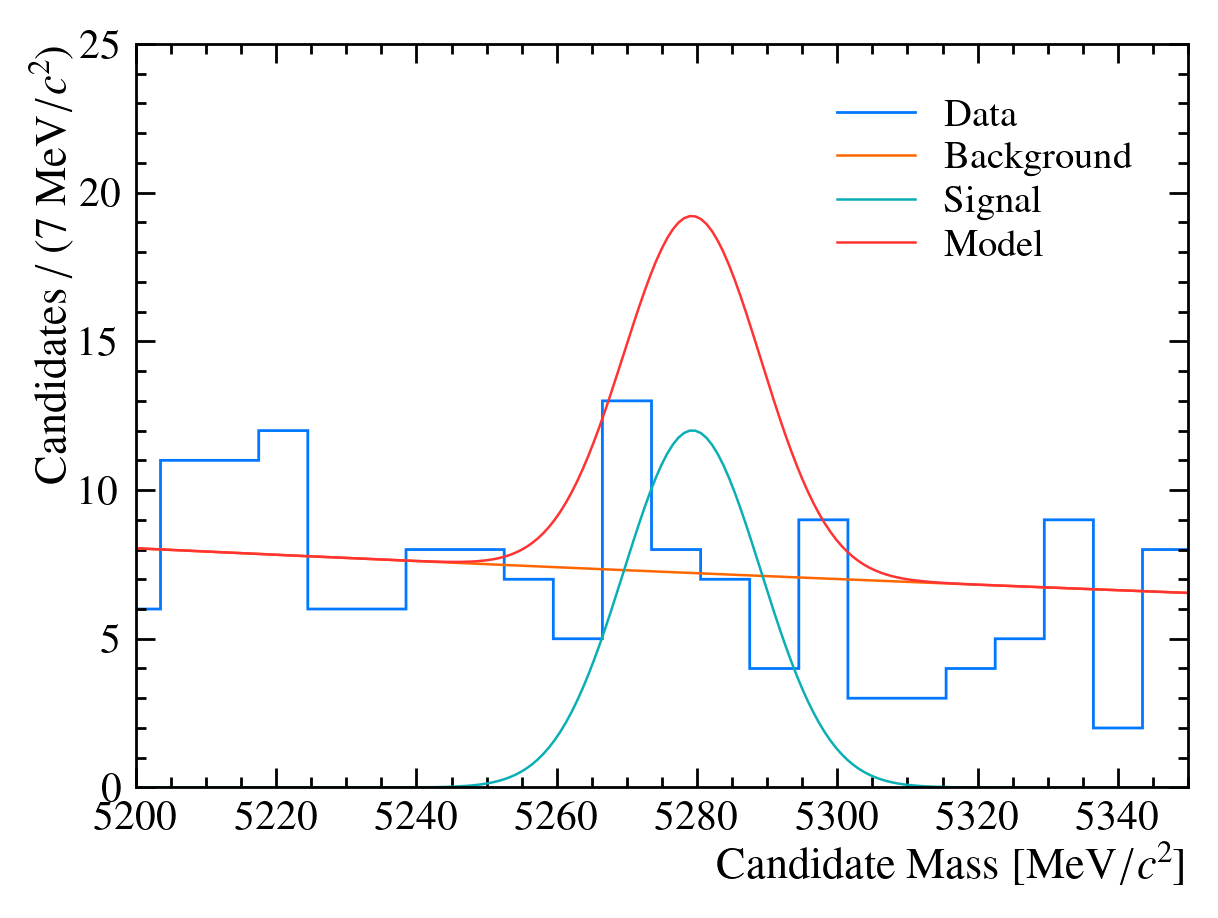

In [9]:
bin_width = 15
fig1, ax1 = histogram_fig(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[bounds[0]-50, bounds[1]+50],
    ylim=[0,50]
)

x = np.linspace(*bounds, 500)
ax1.plot(x, background.ext_pdf(x)*bin_width, label="Background", linewidth=1.8)
ax1.plot(x, signal.ext_pdf(x)*bin_width, label="Signal", linewidth=1.8)
ax1.plot(x, total.ext_pdf(x)*bin_width, label="Model", linewidth=1.8)
ax1.legend()

bin_width = 7
fig2, ax2 = histogram_fig(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[5200, 5350],
    ylim=[0,25]
)

x = np.linspace(5000, 5400, 500)
ax2.plot(x, background.ext_pdf(x)*bin_width, label="Background", linewidth=1.8)
ax2.plot(x, signal.ext_pdf(x)*bin_width, label="Signal", linewidth=1.8)
ax2.plot(x, total.ext_pdf(x)*bin_width, label="Model", linewidth=1.8)
ax2.legend()

In [10]:
def fit_compute_yields(series: pd.Series, obs, model):
    data_np = series.to_numpy()
    data = zfit.Data.from_numpy(array=data_np, obs=obs)

    nll = zfit.loss.ExtendedUnbinnedNLL(model=model, data=data)

    minimizer = zfit.minimize.Minuit()
    minimum = minimizer.minimize(nll)
    minimum.hesse()

    Nsig = float(minimum.params["Nsig"]["value"])
    Nbkg = float(minimum.params["Nbkg"]["value"])

    return Nsig, Nbkg

cut_range = np.linspace(0, 10, 200)
significances = np.array([])
bounds = (5000, 6000)
low_data = []

for t in cut_range:
    cut_df = df[df["Bplus_ENDVERTEX_CHI2"] < t]
        
    obs = zfit.Space("m", limits = bounds)

    mu = zfit.param.ConstantParameter("mu", constant.BPLUS_MASS) # fix gaussian mean

    fwhm = 23
    sigma_from_fwhm = fwhm * 0.424661
    sigma = zfit.Parameter("sigma", sigma_from_fwhm, floating=False) # fixed sigma

    lambda_ = zfit.Parameter("lambda", -0.001)

    # calculate a crude upper limit for Nsig for parameter bounds
    full_pm_20MeV_yield = len(df[(df["Bplus_M"] < constant.BPLUS_MASS + 20) & (df["Bplus_M"] > constant.BPLUS_MASS - 20)])
    # Define the yields (Nsig and Nbkg)
    Nsig = zfit.Parameter("Nsig", 0, 0, full_pm_20MeV_yield)  # Floating signal yield
    Nbkg = zfit.Parameter("Nbkg", 800, 0, 1000)  # Floating background yield

    signal = zfit.pdf.Gauss(mu=mu, sigma=sigma, obs=obs).create_extended(Nsig)
    background = zfit.pdf.Exponential(lam=lambda_, obs=obs).create_extended(Nbkg)

    model = zfit.pdf.SumPDF([signal, background])

    if len(cut_df) < 100:
        low_data.append(True)
    else:
        low_data.append(False)

    try:
        S, B = fit_compute_yields(cut_df["Bplus_M"], obs, model)

        significance = S / np.sqrt(S + B)
        
        print(f"Cut {t}: {significance} ({S=}, {B=})")

        significances = np.append(significances, significance)
    except:
        print("ERROR:", t)
        significances = np.append(significances, 0)
    


ERROR: 0.0
Cut 0.05025125628140704: 0.0001811205671811365 (S=0.0002549572175106812, B=1.9812678827111838)
Cut 0.10050251256281408: 5.393206351994642e-06 (S=1.20455473794847e-05, B=4.988361939880238)
Cut 0.15075376884422112: 0.17240902536703318 (S=0.597063888543832, B=11.395764429342913)
Cut 0.20100502512562815: 0.13194767524321752 (S=0.5107817209034327, B=14.474579229386013)
Cut 0.2512562814070352: 0.6105499129775942 (S=3.1746887573568756, B=23.862402111868334)
Cut 0.30150753768844224: 0.48730899849040826 (S=2.884165798040178, B=32.145144213689655)
Cut 0.35175879396984927: 0.4221819132766029 (S=2.7010654058517196, B=38.23168750776765)
Cut 0.4020100502512563: 0.3522741553792254 (S=2.439925392797162, B=45.532483757526684)
Cut 0.45226130653266333: 0.28692732298289647 (S=2.146807104509658, B=53.83439691905123)
Cut 0.5025125628140704: 0.2230368986173506 (S=1.8109989832925626, B=64.11898618112141)
Cut 0.5527638190954774: 0.22199432536505367 (S=1.9356768896471546, B=74.09379672871476)
Cut 0.6

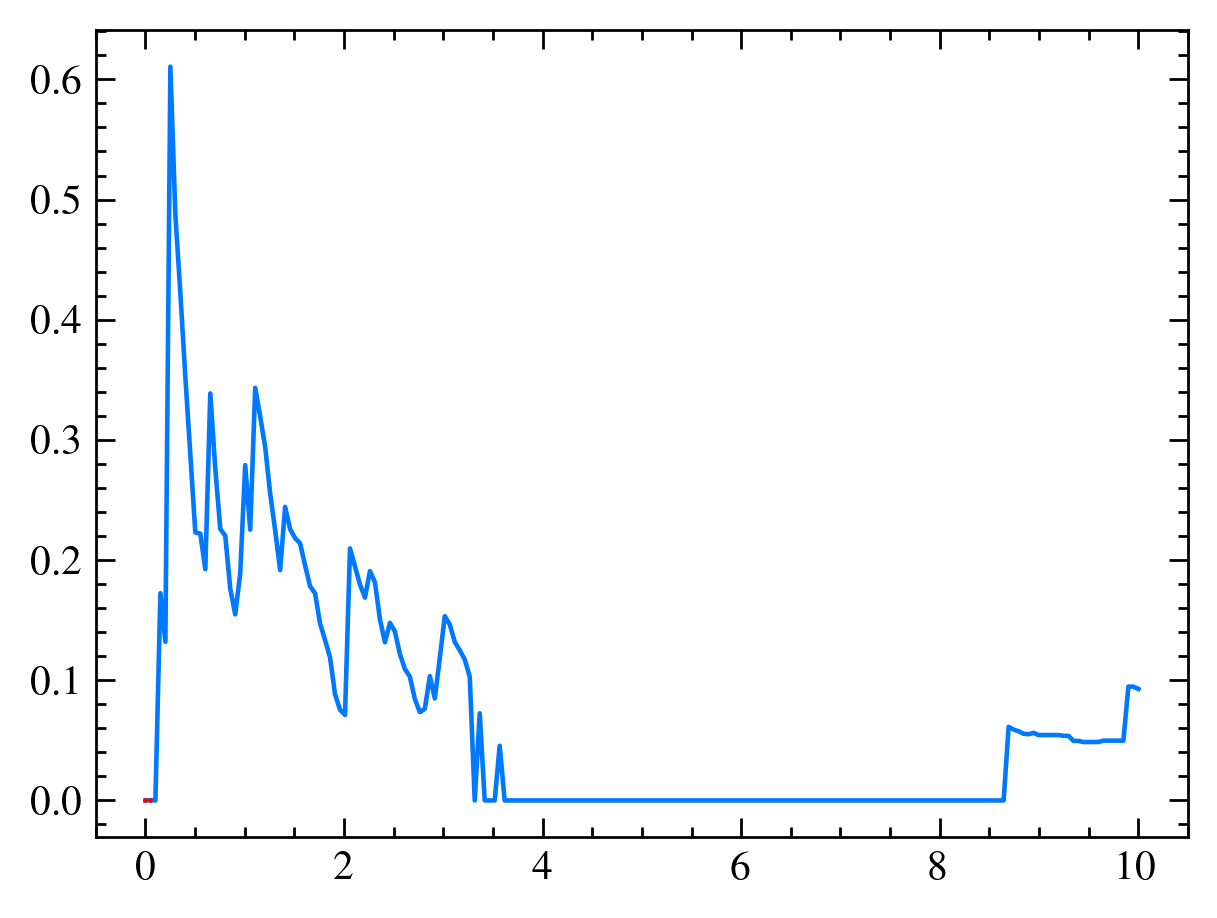

In [11]:
fig, ax = plt.subplots()
ax.plot(cut_range, significances)
# ax.set(xlim=[0, 5])

low_data = np.array(low_data)

ax.scatter(cut_range[low_data], significances[low_data], color="red", zorder=2, s=2)

len(m_av_significance)=181 len(m_av_cut_range)=181 len(m_av_low_data)=181


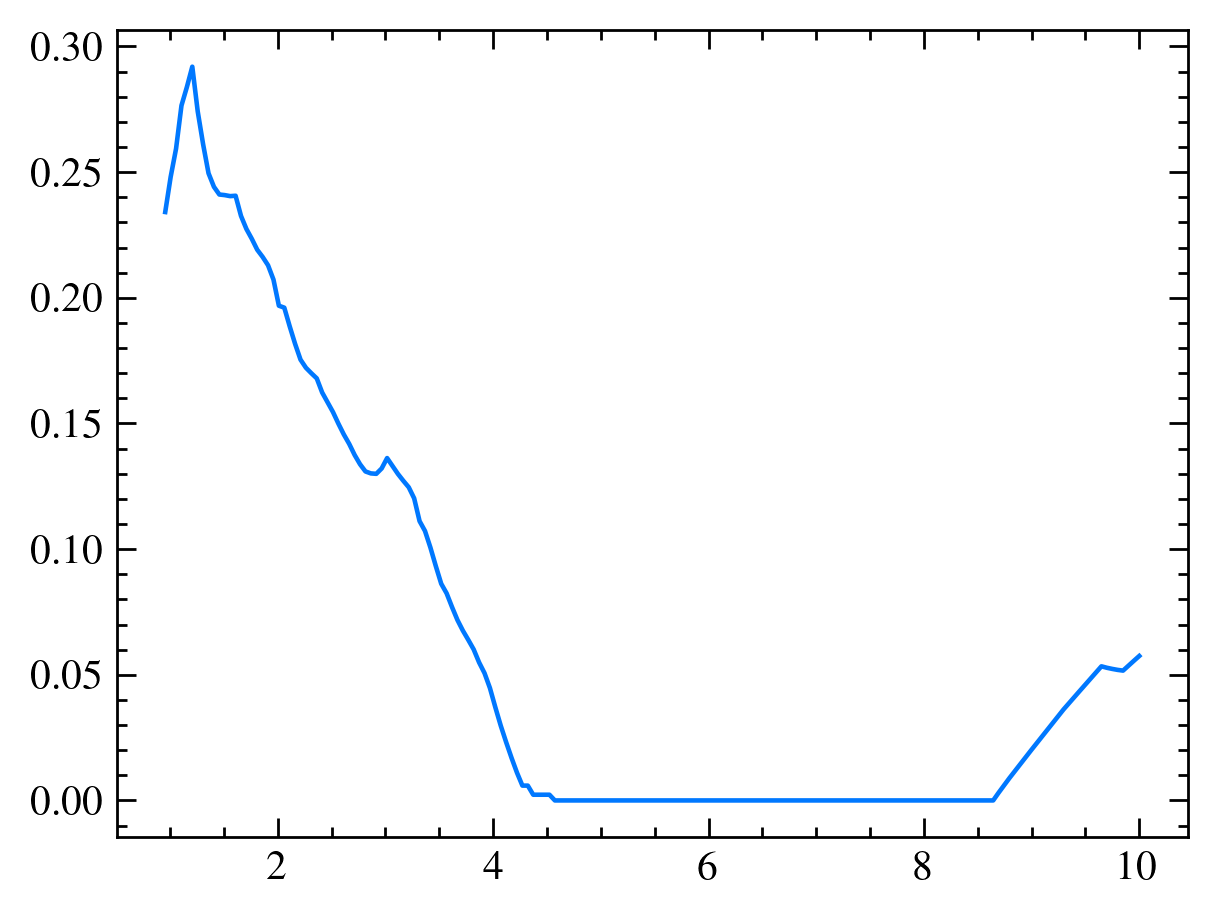

In [12]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

w = 20

m_av_significance = moving_average(significances, w)
m_av_cut_range = cut_range[w-1:]
m_av_low_data = low_data[w-1:]

print(f"{len(m_av_significance)=} {len(m_av_cut_range)=} {len(m_av_low_data)=}")

fig, ax = plt.subplots()
ax.plot(m_av_cut_range, m_av_significance)
# ax.set(xlim=[0, 5])

m_av_low_data = np.array(m_av_low_data)

ax.scatter(m_av_cut_range[m_av_low_data], m_av_significance[m_av_low_data], color="red", zorder=2, s=2)